# Manuscript 2 — Figure S7d, S7e and S7f
### Sensory afferent → ExN / PN connectivity, path overlap, and bubble grid

Everything here is built from four tables that ship with the repository, all under
`data/sensory_exn_matrix/`:

| File | Contents |
| --- | --- |
| `sensory_to_exn_cell_to_cell_matrix_0805.csv` | synapse counts, 161 sensory afferents (rows) × 223 ExN/PN (cols) |
| `all_possible_sensory_exn_pairs_with_overlap.csv` | one row per sensory × ExN/PN pair with `sensory_axon_exn_dendrite_overlap_um` |
| `sensory_pre_labels_0805.csv` | `pt_root_id → sensory_type` for the 161 afferents |
| `exn_post_labels_0805.csv` | `pt_root_id → exn_type` for the 223 ExN/PN |

**Panels**

| Panel | Content | Sensory set | Colour cap |
| --- | --- | --- | --- |
| **Fig. S7d** | synapse-count matrix | all 161 (incl. Aβ-LTMR) | 80th percentile of non-zero entries (= 7) |
| **Fig. S7e** | axon–dendrite path overlap (µm) | 136 (Aβ-LTMR excluded) | 95th percentile (= 591) |
| **Fig. S7f** | cell-type bubble grid | 136 (Aβ-LTMR excluded) | fixed 0–0.14 synapses/10 µm |

Aβ-LTMR afferents are present in the synapse matrix but were not run through the
path-overlap computation, so S7e and S7f cover the other seven subtypes only.

## 0) Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path

DATA_DIR = Path("../data/sensory_exn_matrix")
OUT_DIR = Path("figure4_outputs")
OUT_DIR.mkdir(exist_ok=True)

CM = 1 / 2.54

# raw tag -> display label
SENSORY_LABEL_MAP = {
    "C-COLD": "C-Cold",
    "ad-htmr": "Aδ-HTMR",
    "c-htmr-p": "Peptidergic C-Nociceptor",
    "sst": "C-HTMR/Heat (Sst+)",
    "mrgd": "C-HTMR/Heat (MrgprA3/B4/D+)",
    "cltmr": "C-LTMR",
    "adltmr": "Aδ-LTMR",
    "ab-ltmr": "Aβ-LTMR",
}
EXN_LABEL_MAP = {
    "p1": "P1", "p2_cold": "P2-cold", "p2_noci": "P2-noci", "p2_poly": "P2-poly",
    "v1": "V1", "v2": "V2", "r": "R",
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

# display order
SENSORY_ORDER_D = ["C-COLD", "ad-htmr", "c-htmr-p", "sst", "mrgd", "cltmr", "adltmr", "ab-ltmr"]
EXN_ORDER = ["p1", "p2_cold", "p2_noci", "p2_poly", "v1", "v2", "r",
             "noci_module", "np_module", "cltmr_module", "adltmr_module"]

## 1) Load the synapse-count matrix and the neuron labels

In [2]:
A_pre_by_post = pd.read_csv(DATA_DIR / "sensory_to_exn_cell_to_cell_matrix_0805.csv", index_col=0)
A_pre_by_post.index = A_pre_by_post.index.astype(str)
A_pre_by_post.columns = A_pre_by_post.columns.astype(str)

pre_ann = pd.read_csv(DATA_DIR / "sensory_pre_labels_0805.csv", dtype={"pt_root_id": str})
post_ann = pd.read_csv(DATA_DIR / "exn_post_labels_0805.csv", dtype={"pt_root_id": str})

pre_type_map = pre_ann.set_index("pt_root_id")["sensory_type"].astype(str)
post_type_map = post_ann.set_index("pt_root_id")["exn_type"].astype(str)

print("synapse matrix (sensory × ExN/PN):", A_pre_by_post.shape)
print("\nsensory subtypes:", pre_type_map.value_counts().to_dict())
print("\nExN/PN types:   ", post_type_map.value_counts().to_dict())

synapse matrix (sensory × ExN/PN): (161, 223)

sensory subtypes: {'C-COLD': 25, 'ab-ltmr': 25, 'ad-htmr': 21, 'c-htmr-p': 20, 'adltmr': 18, 'mrgd': 18, 'sst': 18, 'cltmr': 16}

ExN/PN types:    {'v1': 41, 'v2': 36, 'np_module': 27, 'r': 24, 'cltmr_module': 24, 'p2_noci': 16, 'p2_poly': 15, 'adltmr_module': 15, 'noci_module': 10, 'p2_cold': 9, 'p1': 6}


## 2) Sorting helper

Neurons are ordered by cell type (following the display order above), then by root ID
within a type, and the index of each type boundary is recorded so the dashed separators
land in the right place.

In [3]:
def compute_sorted_ids_and_bounds(ids, label_map, cluster_order):
    """Sort `ids` by cell type then ID. Returns (sorted_ids, group_labels,
    tick_centers, boundary_positions). Any label not in `cluster_order` is
    appended after it rather than dropped."""
    ids = pd.Index(ids).astype(str)
    labels = label_map.reindex(ids).fillna("unknown").astype(str)

    complete_order = list(cluster_order)
    for label in labels.unique():
        if label not in complete_order:
            complete_order.append(label)

    order_df = (
        pd.DataFrame({"id": ids,
                      "label": pd.Categorical(labels, categories=complete_order, ordered=True)})
        .sort_values(["label", "id"], kind="mergesort")
        .reset_index(drop=True)
    )

    starts, ends, group_labels = [], [], []
    for label, group in order_df.groupby("label", observed=True, sort=False):
        starts.append(group.index[0]); ends.append(group.index[-1] + 1)
        group_labels.append(str(label))

    centers = [(s + e - 1) / 2 for s, e in zip(starts, ends)]
    boundaries = [e - 0.5 for e in ends[:-1]]
    return order_df["id"].tolist(), group_labels, centers, boundaries


def plot_sensory_heatmap(matrix, *, row_info, col_info, row_label_map, col_label_map,
                         cbar_label, out_path, vmax, ylabel, figsize_cm=(6, 6)):
    """Neuron-level heatmap, rows = postsynaptic ExN/PN, cols = presynaptic sensory."""
    _, row_labels, row_centers, row_boundaries = row_info
    _, col_labels, col_centers, col_boundaries = col_info

    fig, ax = plt.subplots(figsize=(figsize_cm[0] * CM, figsize_cm[1] * CM))
    im = ax.imshow(np.clip(matrix.to_numpy(dtype=float), 0, vmax), aspect="auto",
                   cmap="Blues", vmin=0, vmax=vmax, interpolation="nearest",
                   rasterized=True)

    ax.set_xticks(col_centers)
    ax.set_xticklabels([col_label_map.get(x, x) for x in col_labels],
                       rotation=-45, ha="left", fontsize=4)
    ax.set_yticks(row_centers)
    ax.set_yticklabels([row_label_map.get(x, x) for x in row_labels], fontsize=4)

    for x in col_boundaries:
        ax.axvline(x, linestyle="--", color="red", linewidth=0.6)
    for y in row_boundaries:
        ax.axhline(y, linestyle="--", color="red", linewidth=0.6)

    ax.set_xlabel("Presynaptic sensory neuron", fontsize=7)
    ax.set_ylabel(ylabel, fontsize=7)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(cbar_label, fontsize=5)
    cbar.ax.tick_params(labelsize=5)

    plt.tight_layout()
    fig.savefig(out_path, format="svg", dpi=600, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

## Figure S7d — sensory → ExN/PN synapse counts

All 161 afferents, including Aβ-LTMR. Every annotated neuron is forced into the matrix
(cells absent from the connectivity table become 0), so the panel shows the complete
population rather than only the connected subset.

S7d cap = P80 of non-zero synapse counts = 7


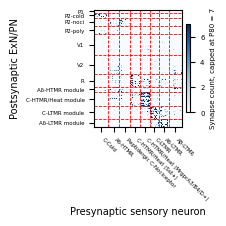

Saved: figure4_outputs/figureS7d_sensory_to_exn_synapse_count.svg


In [4]:
# rows = postsynaptic ExN/PN, cols = presynaptic sensory; include zero-connection cells
A_d = (A_pre_by_post.T
       .reindex(index=post_ann["pt_root_id"].tolist(), columns=pre_ann["pt_root_id"].tolist())
       .fillna(0).astype(int))

row_info_d = compute_sorted_ids_and_bounds(A_d.index, post_type_map, EXN_ORDER)
col_info_d = compute_sorted_ids_and_bounds(A_d.columns, pre_type_map, SENSORY_ORDER_D)
A_d_sorted = A_d.reindex(index=row_info_d[0], columns=col_info_d[0]).fillna(0).astype(int)

vals = A_d_sorted.to_numpy(dtype=float)
vmax_S7d = float(np.percentile(vals[vals > 0], 80))
print(f"S7d cap = P80 of non-zero synapse counts = {vmax_S7d:g}")
assert np.isclose(vmax_S7d, 7.0), vmax_S7d  # published colorbar note: "capped at P80 = 7"

plot_sensory_heatmap(
    A_d_sorted, row_info=row_info_d, col_info=col_info_d,
    row_label_map=EXN_LABEL_MAP, col_label_map=SENSORY_LABEL_MAP,
    cbar_label=f"Synapse count, capped at P80 = {vmax_S7d:.3g}",
    ylabel="Postsynaptic ExN/PN",
    out_path=OUT_DIR / "figureS7d_sensory_to_exn_synapse_count.svg",
    vmax=vmax_S7d,
)

## 3) Path-overlap matrix

`all_possible_sensory_exn_pairs_with_overlap.csv` is the long form: one row per
(sensory, ExN/PN) pair. Pivot it to a matrix aligned on the same axes. Aβ-LTMR afferents
were not run through the overlap computation, so they are absent here — the matrix covers
136 × 223 pairs. Pairs with no overlap measurement stay `NaN` and render white.

In [5]:
overlap_long = pd.read_csv(DATA_DIR / "all_possible_sensory_exn_pairs_with_overlap.csv",
                           dtype={"pre_id": str, "post_id": str})
overlap_long["sensory_axon_exn_dendrite_overlap_um"] = pd.to_numeric(
    overlap_long["sensory_axon_exn_dendrite_overlap_um"], errors="coerce"
)

O_pre_by_post = overlap_long.pivot_table(
    index="pre_id", columns="post_id",
    values="sensory_axon_exn_dendrite_overlap_um", aggfunc="first",
)

# labels as used in the overlap table (already display-form)
sensory_label_map = (overlap_long[["pre_id", "pre_label"]]
                     .drop_duplicates("pre_id").set_index("pre_id")["pre_label"].astype(str))
exn_label_map = (overlap_long[["post_id", "post_label"]]
                 .drop_duplicates("post_id").set_index("post_id")["post_label"].astype(str))

print("overlap pairs:", len(overlap_long),
      f"= {overlap_long.pre_id.nunique()} sensory × {overlap_long.post_id.nunique()} ExN/PN")
print("overlap matrix:", O_pre_by_post.shape)

overlap pairs: 30328 = 136 sensory × 223 ExN/PN
overlap matrix: (136, 223)


## Figure S7e — sensory → ExN/PN axon–dendrite path overlap

S7e cap = P95 of non-zero overlap = 591.2 µm


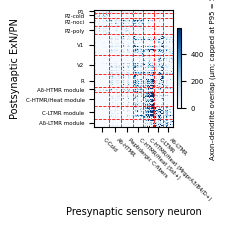

Saved: figure4_outputs/figureS7e_sensory_to_exn_path_overlap.svg


In [6]:
SENSORY_ORDER_DISPLAY = ["C-Cold", "Aδ-HTMR", "Peptidergic C-Nociceptor",
                         "C-HTMR/Heat (Sst+)", "C-HTMR/Heat (MrgprA3/B4/D+)",
                         "C-LTMR", "Aδ-LTMR"]
EXN_ORDER_DISPLAY = ["P1", "P2-cold", "P2-noci", "P2-poly", "V1", "V2", "R",
                     "Aδ-HTMR module", "C-HTMR/Heat module", "C-LTMR module", "Aδ-LTMR module"]

O_e = O_pre_by_post.T  # rows = postsynaptic ExN/PN, cols = presynaptic sensory

row_info_e = compute_sorted_ids_and_bounds(O_e.index, exn_label_map, EXN_ORDER_DISPLAY)
col_info_e = compute_sorted_ids_and_bounds(O_e.columns, sensory_label_map, SENSORY_ORDER_DISPLAY)
O_e_sorted = O_e.reindex(index=row_info_e[0], columns=col_info_e[0])

ovals = O_e_sorted.to_numpy(dtype=float)
vmax_S7e = float(np.percentile(ovals[np.isfinite(ovals) & (ovals > 0)], 95))
print(f"S7e cap = P95 of non-zero overlap = {vmax_S7e:.1f} µm")

plot_sensory_heatmap(
    O_e_sorted, row_info=row_info_e, col_info=col_info_e,
    row_label_map={}, col_label_map={"Peptidergic C-Nociceptor": "Peptidergic C-fibers"},
    cbar_label=f"Axon–dendrite overlap (µm; capped at P95 = {vmax_S7e:.1f})",
    ylabel="Postsynaptic ExN/PN",
    out_path=OUT_DIR / "figureS7e_sensory_to_exn_path_overlap.svg",
    vmax=vmax_S7e,
)

## Figure S7f — sensory subtype → ExN/PN bubble grid

Per (sensory subtype, ExN/PN type) block, over the pairs with `overlap > 0`:

- **area** = total synapses in the block / number of overlapping pairs
- **colour** = mean synapse density in synapses per 10 µm of overlap, on a **fixed**
  0–0.14 scale (not a percentile cap), so this panel is directly comparable with Fig. 4f

In [7]:
A_f = A_pre_by_post.reindex(index=O_pre_by_post.index, columns=O_pre_by_post.columns).fillna(0.0)
O_f = O_pre_by_post

ids_by_pre = {t: sensory_label_map[sensory_label_map == t].index.intersection(A_f.index)
              for t in SENSORY_ORDER_DISPLAY}
ids_by_post = {t: exn_label_map[exn_label_map == t].index.intersection(A_f.columns)
               for t in EXN_ORDER_DISPLAY}

density_overlap_only = pd.DataFrame(np.nan, index=SENSORY_ORDER_DISPLAY, columns=EXN_ORDER_DISPLAY)
avg_syn_overlap_pair = pd.DataFrame(np.nan, index=SENSORY_ORDER_DISPLAY, columns=EXN_ORDER_DISPLAY)

for pre in SENSORY_ORDER_DISPLAY:
    rows = list(ids_by_pre[pre])
    for post in EXN_ORDER_DISPLAY:
        cols = list(ids_by_post[post])
        if not rows or not cols:
            continue

        blockA = A_f.loc[rows, cols].to_numpy(float)
        blockO = O_f.loc[rows, cols].to_numpy(float)

        overlap_mask = np.isfinite(blockO) & (blockO > 0)
        n_overlap_pairs = int(overlap_mask.sum())
        total_syn = float(np.nansum(np.where(np.isfinite(blockA), blockA, 0.0)))

        with np.errstate(divide="ignore", invalid="ignore"):
            density = np.divide(blockA, blockO, where=overlap_mask)
        density = np.where(overlap_mask & np.isfinite(density), density, np.nan)
        if np.isfinite(density).any():
            density_overlap_only.loc[pre, post] = np.nanmean(density)

        if n_overlap_pairs > 0:
            avg_syn_overlap_pair.loc[pre, post] = total_syn / n_overlap_pairs

# convert density to synapses per 10 µm
density_overlap_only_plot = density_overlap_only * 10

print("Avg synapses per overlapping pair:")
print(avg_syn_overlap_pair.round(2).to_string())

Avg synapses per overlapping pair:
                               P1  P2-cold  P2-noci  P2-poly    V1    V2     R  Aδ-HTMR module  C-HTMR/Heat module  C-LTMR module  Aδ-LTMR module
C-Cold                       0.00     1.28     0.08     0.29  0.00  0.01  0.00            0.31                0.00           0.00             NaN
Aδ-HTMR                      0.06     0.00     0.96     0.44  0.03  0.48  0.31            2.22                0.26           0.08            0.00
Peptidergic C-Nociceptor     0.00     0.05     1.37     0.24  0.01  0.16  0.29            1.15                0.61           0.16            0.00
C-HTMR/Heat (Sst+)           0.00     0.00     0.05     0.04  0.01  0.07  3.37            0.68                1.83           0.05            0.00
C-HTMR/Heat (MrgprA3/B4/D+)  0.00     0.00     0.01     0.00  0.13  0.07  1.13            0.56                6.08           0.28            0.02
C-LTMR                       0.00     0.00     0.02     0.00  0.02  0.19  0.19           

In [8]:
def _area_scaled_sizes(vals, max_area_pts2=400.0, size_vmax=None):
    """Marker AREA proportional to value."""
    vals = np.asarray(vals, float)
    if size_vmax is None:
        size_vmax = np.nanmax(vals)
    if not np.isfinite(size_vmax) or size_vmax <= 0:
        return np.zeros_like(vals)
    return vals / size_vmax * max_area_pts2


def add_size_legend(ax, size_vmax, ticks_abs, max_diam_pts=7):
    handles = [
        ax.scatter([], [], s=(v / size_vmax) * (max_diam_pts ** 2),
                   color="#0b3c78", edgecolors="none")
        for v in ticks_abs
    ]
    return ax.legend(handles, [f"{v:.2f}" for v in ticks_abs], title="Avg Syn count",
                     loc="upper left", bbox_to_anchor=(1.02, 1.0), frameon=True,
                     borderpad=0.3, labelspacing=0.8, handletextpad=0.5,
                     fontsize=5, title_fontsize=5)


def bubble_grid(size_df, color_df, pre_order, post_order, *, title="", cmap="Blues",
                max_diam_pts=7, fig_cm=(4, 5), color_vmax=0.14, size_vmax=None,
                size_legend_ticks_abs=(1, 2, 4, 8), save_svg_path=None):
    """Bubble grid: AREA proportional to `size_df`, colour proportional to `color_df`
    on a FIXED 0..color_vmax scale (synapses / 10 µm overlap)."""
    size_df = size_df.reindex(index=pre_order, columns=post_order)
    color_df = color_df.reindex(index=pre_order, columns=post_order)

    xs, ys, sizes, colors = [], [], [], []
    for i, pre in enumerate(pre_order):
        for j, post in enumerate(post_order):
            s, c = size_df.loc[pre, post], color_df.loc[pre, post]
            if np.isfinite(s) and np.isfinite(c):
                xs.append(i); ys.append(j); sizes.append(s); colors.append(c)
    xs, ys = np.array(xs), np.array(ys)
    sizes, colors = np.array(sizes), np.array(colors)

    norm = mpl.colors.Normalize(vmin=0, vmax=color_vmax)

    mpl.rcParams.update({"font.size": 5, "axes.titlesize": 5, "axes.labelsize": 5,
                         "xtick.labelsize": 5, "ytick.labelsize": 5, "legend.fontsize": 5})
    fig, ax = plt.subplots(figsize=(fig_cm[0] / 2.54, fig_cm[1] / 2.54), dpi=300)

    if size_vmax is None:
        size_vmax = np.nanmax(sizes)
    sc = ax.scatter(xs, ys, s=_area_scaled_sizes(sizes, max_diam_pts ** 2, size_vmax),
                    c=colors, cmap=cmap, norm=norm, edgecolors="none")

    add_size_legend(ax, size_vmax=size_vmax, ticks_abs=size_legend_ticks_abs,
                    max_diam_pts=max_diam_pts)

    ax.set_xticks(np.arange(len(pre_order)))
    ax.set_yticks(np.arange(len(post_order)))
    ax.set_xticklabels(pre_order, rotation=-45, ha="left")
    ax.set_yticklabels(post_order)
    ax.set_xlim(-0.5, len(pre_order) - 0.5)
    ax.set_ylim(len(post_order) - 0.5, -0.5)
    ax.grid(linestyle=":", linewidth=0.3)
    ax.set_title(title)

    cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.08)
    cbar.set_ticks([0.00, 0.035, 0.07, 0.105, 0.14])
    cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.2f}"))
    cbar.set_label("Avg. normalized syn. density\n(synapses / 10 µm overlap)",
                   fontsize=5, labelpad=4)
    cbar.ax.tick_params(labelsize=5)

    if save_svg_path:
        plt.savefig(save_svg_path, dpi=300, bbox_inches="tight")
    plt.show()

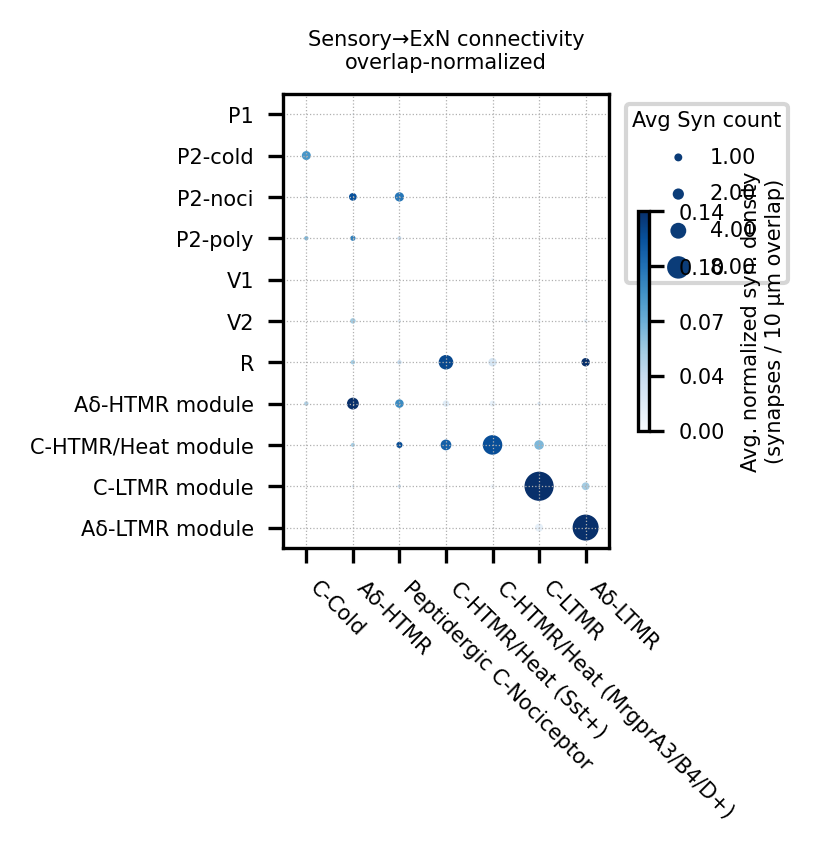

In [9]:
bubble_grid(
    size_df=avg_syn_overlap_pair,
    color_df=density_overlap_only_plot,
    pre_order=SENSORY_ORDER_DISPLAY,
    post_order=EXN_ORDER_DISPLAY,
    title="Sensory→ExN connectivity\noverlap-normalized",
    cmap="Blues",
    max_diam_pts=7,
    fig_cm=(4, 5),
    color_vmax=0.14,
    size_vmax=float(np.nanmax(avg_syn_overlap_pair.to_numpy())),
    size_legend_ticks_abs=[1, 2, 4, 8],
    save_svg_path=OUT_DIR / "figureS7f_sensory_to_exn_bubble_grid.svg",
)

avg_syn_overlap_pair.to_csv(OUT_DIR / "sensory_avg_synapses_per_overlapping_pair.csv")
density_overlap_only_plot.to_csv(OUT_DIR / "sensory_mean_density_per_10um_overlap.csv")